# MeanFlow

A simple tutorial of MeanFlow[Geng25] using MNIST dataset.

Author: Minsu Kang

Email: mskang1478@gmail.com

In [1]:
import torch, os
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt
from torchvision.utils import save_image, make_grid

from tqdm import tqdm
from torch.optim import AdamW

In [6]:
dataset_path = '~/datasets'

dataset = "MNIST"
gpu_id = 1
cuda = True

hidden_dim = 256
n_layers = 8

lr = 5e-5

n_epochs = 200
train_batch_size = 128

inference_batch_size = 64

seed = 1234

os.environ['CUDA_VISIBLE_DEVICES'] = "{}".format(gpu_id)
DEVICE = torch.device("cuda:0".format(gpu_id) if cuda else "cpu")
img_size = (32, 32, 3)   if dataset == "CIFAR10" else (28, 28, 1) # (width, height, channels)
hidden_dims = [hidden_dim for _ in range(n_layers)]

torch.manual_seed(seed)
np.random.seed(seed)

## Step 1. Load (or download) Dataset

In [7]:
from torchvision.datasets import MNIST, CIFAR10
import torchvision.transforms as transforms
from torch.utils.data import DataLoader


transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x*2-1) 
])

kwargs = {'num_workers': 1, 'pin_memory': True} 

if dataset == 'CIFAR10':
    train_dataset = CIFAR10(dataset_path, transform=transform, train=True, download=True)
    test_dataset  = CIFAR10(dataset_path, transform=transform, train=False, download=True)
else:
    train_dataset = MNIST(dataset_path, transform=transform, train=True, download=True)
    test_dataset  = MNIST(dataset_path, transform=transform, train=False, download=True)

train_loader = DataLoader(dataset=train_dataset, batch_size=train_batch_size, shuffle=True, **kwargs)
test_loader  = DataLoader(dataset=test_dataset,  batch_size=inference_batch_size, shuffle=False,  **kwargs)

## Step 2. Define our model: MeanFlow

In this tutorial, we use **MeanFlow without classifier-free guidance** which is proposed in the paper.

For comparison, we use a simple stacked-convolution model with various dilations as like [Denoising Diffusion Probabilistic Model(DDPM) tutorial](https://github.com/Jackson-Kang/Pytorch-Diffusion-Model-Tutorial). The number of trainable parameters and other details are almost same.

In [8]:
class ConvBlock(nn.Conv2d):
    """
        Conv2D Block
            Args:
                x: (N, C_in, H, W)
            Returns:
                y: (N, C_out, H, W)
    """

    def __init__(self, in_channels, out_channels, kernel_size, activation_fn=None, drop_rate=0.,
                    stride=1, padding='same', dilation=1, groups=1, bias=True, gn=False, gn_groups=8):
        
        if padding == 'same':
            padding = kernel_size // 2 * dilation

        super(ConvBlock, self).__init__(in_channels, out_channels, kernel_size,
                                            stride=stride, padding=padding, dilation=dilation,
                                            groups=groups, bias=bias)

        self.activation_fn = nn.SiLU() if activation_fn else None
        self.group_norm = nn.GroupNorm(gn_groups, out_channels) if gn else None
        
    def forward(self, x, r_embedding=None, t_embedding=None, residual=False):
        
        if residual:
            # timestep embedding was only applied to residual blocks of U-Net
            x = x + t_embedding + r_embedding
            y = x
            x = super(ConvBlock, self).forward(x)
            y = y + x
        else:
            y = super(ConvBlock, self).forward(x)
        y = self.group_norm(y) if self.group_norm is not None else y
        y = self.activation_fn(y) if self.activation_fn is not None else y
        
        return y

In [9]:
class Model(nn.Module):
    
    def __init__(self, image_resolution, hidden_dims=[256, 256]):
        super(Model, self).__init__()
        
        _, _, img_C = image_resolution
        
        self.in_project = ConvBlock(img_C, hidden_dims[0], kernel_size=7)
        
        self.time_project_t = nn.Sequential(
                                 ConvBlock(1, hidden_dims[0], kernel_size=1, activation_fn=True),
                                 ConvBlock(hidden_dims[0], hidden_dims[1], kernel_size=1))

        self.time_project_r = nn.Sequential(
                                 ConvBlock(1, hidden_dims[0], kernel_size=1, activation_fn=True),
                                 ConvBlock(hidden_dims[0], hidden_dims[1], kernel_size=1))
        
        self.convs = nn.ModuleList([ConvBlock(in_channels=hidden_dims[0], out_channels=hidden_dims[0], kernel_size=3)])
        
        for idx in range(1, len(hidden_dims)):
            self.convs.append(ConvBlock(hidden_dims[idx-1], hidden_dims[idx], kernel_size=3, dilation=3**((idx-1)//2),
                                                    activation_fn=True, gn=True, gn_groups=8))                                
                               
        self.out_project = ConvBlock(hidden_dims[-1], out_channels=img_C, kernel_size=3)

    def get_z_t(self, x, t, e):
        return (1-t) * x + t * e

    def get_instantaneous_velocity_v(self, e, x):
        return e - x                             # get derivative of z_t
    
    def forward(self, z_t, r, t):
        """
            Estimate vector field given x_t and time embedding.
        """
        
        r_embedding = self.time_project_r(r)
        t_embedding = self.time_project_t(t)
        
        y = self.in_project(z_t)
        
        for i in range(len(self.convs)):
            y = self.convs[i](y, r_embedding, t_embedding, residual=True)
            
        v_t = self.out_project(y)
        return v_t

    @torch.no_grad()
    def sample(self, shape, n_steps: int = 1, DEVICE='cuda:0'):
        """
        Multi-step sampling:
          • shape      : (B, C, H, W)
          • n_steps    : number of Euler steps (≥1)
          • schedule   : 'linear' or list/np.ndarray of explicit t values (1→0)
        Returns:
          x ≈ data sample drawn from p_data
        """

        B = shape[0]
        make_time = lambda v: torch.full((B,1,1,1), v, device=DEVICE)
        t_list = torch.linspace(1.0, 0.0, n_steps + 1, device=DEVICE)
        
        # Step-0: z_1 = e (pure Gaussian)
        z = torch.randn(shape, device=DEVICE)

        # Euler 역적분: t = 1 → 0
        for i in range(n_steps):
            t_i   = make_time(t_list[i])
            r_i   = make_time(t_list[i + 1])         # 다음 스텝 시간이 r
            u_t   = self(z, r=r_i, t=t_i)            # 평균 속도 추정
            d_t  = t_list[i] - t_list[i + 1] 
            z     = z - u_t * d_t                    # z_{r} = z_t - u
                                                     # (Δt = 1/n_steps 로 흡수)
        return z
    
model = Model(image_resolution=img_size,
                 hidden_dims=hidden_dims).to(DEVICE)

In [10]:
optimizer = AdamW(model.parameters(), lr=lr, betas=(0.9, 0.99))

## Step 3. Train MeanFlow model

In [11]:
def sample_r_t(batch_size, flow_ratio=0.5, DEVICE=None):
    t = torch.rand(batch_size, 1, 1, 1, device=DEVICE)
    r =  torch.rand_like(t) * t
    mask = torch.rand_like(t) < flow_ratio   # True → r==t
    r[mask] = t[mask]
    
    return r, t

In [12]:
def jvp(fn, z_t, r, t, v):
    _, du_dt = torch.autograd.functional.jvp(fn, (z_t, r, t), (v, torch.zeros_like(r), torch.ones_like(t)), create_graph=True)
    return du_dt

In [13]:
def adaptive_l2(error, gamma=0.5, c=1e-3):
    delta_sq = error.pow(2).mean(dim=(1,2,3))
    w = (delta_sq + c).pow(-(1-gamma)).detach()
    return (w * delta_sq).mean(), delta_sq.mean()


In [14]:
print("Start training MeanFlow...")
model.train()

for epoch in range(n_epochs):
    total_loss = 0
    for batch_idx, (x, _) in enumerate(train_loader):
        optimizer.zero_grad()

        # sample Gaussian normal and target data
        x = x.to(DEVICE)
        e = torch.randn_like(x)

        B = x.shape[0]
        
        r, t = sample_r_t(B, DEVICE=DEVICE)
        
        # get noise-interpolated data
        z_t = model.get_z_t(x, t, e)
        v = model.get_instantaneous_velocity_v(e, x)
        
        # target velocity
        u = model(z_t, r, t)
        du_dt = jvp(model.forward, z_t, r, t, v)
        u_tgt = v - (t-r) * du_dt

        # conditional flow matching loss. model learns 
        loss = ((u - u_tgt.detach()) ** 2).mean()
        total_loss += loss.item()
        
        loss.backward() 
        optimizer.step()

        grad_norm = sum(p.grad.norm().item() for p in model.parameters() if p.grad is not None)
        du_dt_mean = du_dt.abs().mean().item()

        if batch_idx % 100 == 0:
            print("\t\tMeanFlow loss: ", loss.item(), "  grad_norm:", grad_norm, "  du_dt_mean: ", du_dt_mean)
        
    print("\tEpoch", epoch + 1, "complete!", "  mean flow loss: ", total_loss / len(train_loader))

    
print("Finish!!")

Start training MeanFlow...
		MeanFlow loss:  1.6447702646255493   grad_norm: 90.32209435105324   du_dt_mean:  0.4216236174106598
		MeanFlow loss:  0.48819074034690857   grad_norm: 3.1471896432340145   du_dt_mean:  1.1810969114303589
		MeanFlow loss:  0.4670459032058716   grad_norm: 15.501893498003483   du_dt_mean:  1.1172221899032593
		MeanFlow loss:  0.4397744834423065   grad_norm: 6.555732642300427   du_dt_mean:  1.3143011331558228
		MeanFlow loss:  0.5001552700996399   grad_norm: 14.939854767173529   du_dt_mean:  1.1449464559555054
	Epoch 1 complete!   Mean Flow Loss:  0.51295654389904
		MeanFlow loss:  0.5383952856063843   grad_norm: 6.404763637110591   du_dt_mean:  1.4783393144607544
		MeanFlow loss:  0.49776020646095276   grad_norm: 9.437842760235071   du_dt_mean:  1.204225778579712
		MeanFlow loss:  0.37457266449928284   grad_norm: 6.306956137064844   du_dt_mean:  1.405677318572998
		MeanFlow loss:  0.4601725935935974   grad_norm: 3.5955428916495293   du_dt_mean:  0.940342307090

# Step 4. Generate sample from Trained Model

In [15]:
def show_image(x, idx):
    fig = plt.figure()
    plt.imshow(x[idx].transpose(0, 1).transpose(1, 2).detach().cpu().numpy())

In [16]:
model.eval()

B = 1
W, H, C = img_size

### Exploring optimal value of the # of conditional flow, $T$

#### Generation result when T=1

In [17]:
x_hats_01 = model.sample(shape=[B, C, W, H], n_steps=1, DEVICE=DEVICE)

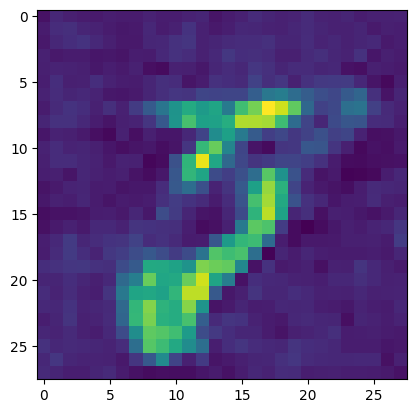

In [18]:
show_image(x_hats_01, 0)

#### Generation result when T=2

In [19]:
x_hats_02 = model.sample(shape=[B, C, W, H], n_steps=2, DEVICE=DEVICE)

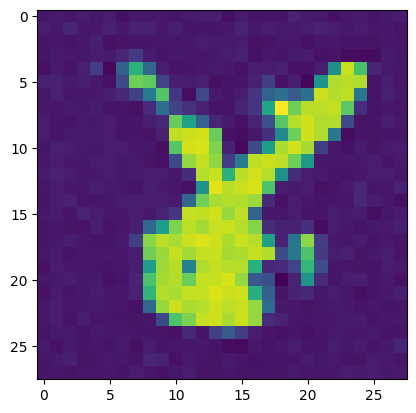

In [20]:
show_image(x_hats_02, 0)

#### Generation result when T=4

In [60]:
x_hats_05 = model.sample(shape=[B, C, W, H], n_steps=5, DEVICE=DEVICE)

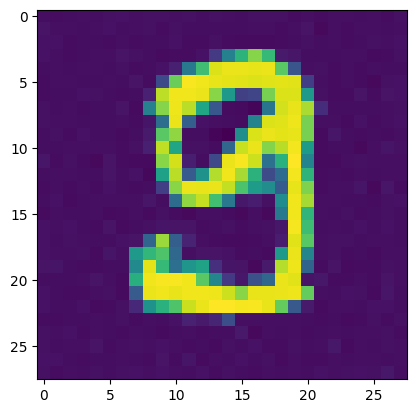

In [61]:
show_image(x_hats_05, 0)

#### Generation result when T=10

In [23]:
x_hats_10 = model.sample(shape=[B, C, W, H], n_steps=10, DEVICE=DEVICE)

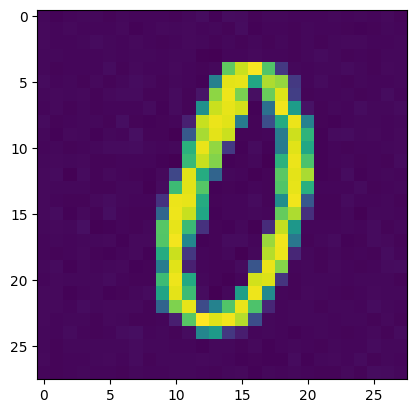

In [62]:
show_image(x_hats_10, 0)

In [63]:
x_hats_25 = model.sample(shape=[B, C, W, H], n_steps=25, DEVICE=DEVICE)

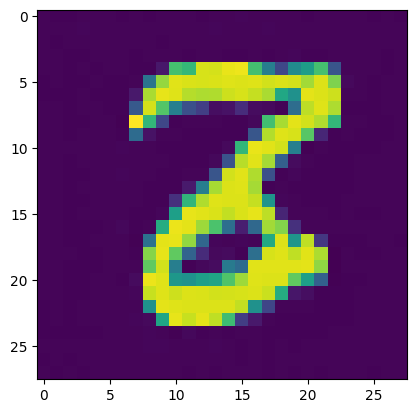

In [64]:
show_image(x_hats_25, 0)

In [99]:
x_hats_50 = model.sample(shape=[B, C, W, H], n_steps=50, DEVICE=DEVICE)

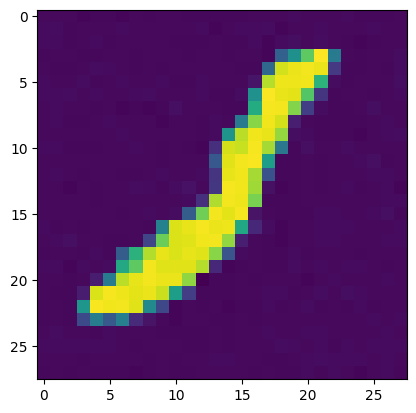

In [100]:
show_image(x_hats_50, 0)

### Comparison with Ground-truth Samples

In [111]:
B = 16
x_hats = model.sample(shape=[B, C, W, H], n_steps=2, DEVICE=DEVICE)

In [115]:
def draw_sample_image(x, postfix):
  
    plt.figure(figsize=(4,4))
    plt.axis("off")
    plt.title("Visualization of {}".format(postfix))
    plt.imshow(np.transpose(make_grid(x.detach().cpu(), padding=2, normalize=True), (1, 2, 0)))

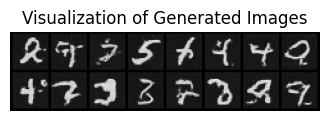

In [116]:
draw_sample_image(x_hats, "Generated Images")

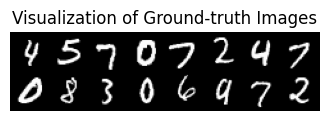

In [117]:
draw_sample_image(x[:B], "Ground-truth Images")

## References

* [Neural Ordinary Differential Equations](https://arxiv.org/abs/1806.07366), Chen et. al., 2018
* [Denoising Diffusion Probabilistic Models](https://arxiv.org/abs/2006.11239), J. Ho et. al., 2020
* [Flow Matching for Generative Modeling](https://arxiv.org/abs/2210.02747), Lipman et. al., 2022
* [Mean Flows for One-step Generative Modeling](https://arxiv.org/abs/2505.13447), Geng et. al., 2025